# Проект: Статистический анализ данных

## Задание

*Вы аналитик популярного сервиса аренды самокатов GoFast. Вам передали данные о некоторых пользователях из нескольких городов, а также об их поездках. Проанализируйте данные и проверьте некоторые гипотезы, которые могут помочь бизнесу вырасти.
Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
- без подписки
    - абонентская плата отсутствует;
    - стоимость одной минуты поездки — 8 рублей;
    - стоимость старта (начала поездки) — 50 рублей;
- с подпиской Ultra
    - абонентская плата — 199 рублей в месяц;
    - стоимость одной минуты поездки — 6 рублей;
    - стоимость старта — бесплатно.

Описание данных
В основных данных есть информация о пользователях, их поездках и подписках.

Пользователи — users_go.csv
- user_id	уникальный идентификатор пользователя
- name	имя пользователя
- age	возраст
- city	город
- subscription_type	тип подписки (free, ultra)

Поездки — rides_go.csv
- user_id	уникальный идентификатор пользователя
- distance	расстояние, которое пользователь проехал в текущей сессии (в метрах)
- duration	продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
- date	дата совершения поездки

Подписки — subscriptions_go.csv
- subscription_type	тип подписки
- minute_price	стоимость одной минуты поездки по данной подписке
- start_ride_price	стоимость начала поездки
- subscription_fee	стоимость ежемесячного платежа*

Начнём:

In [374]:
import pandas as pd
import numpy as np
import os
from pandas.api.types import is_numeric_dtype
from pandas.api.types import is_string_dtype
from scipy import stats as st
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns

вспомогательные функции:

In [375]:
def correct_path (csv_name):
    if not os.path.exists(csv_name):
        return '/datasets/' + csv_name
    return csv_name

def check_na (data):
    for (field_name, field_content) in data.items():
        display (f"amount of NaN in {field_name} is {data[field_name].isna().sum()}, \
                 {(data[field_name].isna().sum() / len(data) * 100).astype('int')}%")
        
def print_hypothesis (pvalue, alpha, H0, H1):
    if results.pvalue < alpha:
        print(f'pvalue {results.pvalue} ~{results.pvalue:.3f} \
менее уровня значимости {alpha}, \
потому мы отвергаем H0 и принимаем H1:\n{H1}')
    else:
        print(f'pvalue {results.pvalue} ~{results.pvalue:.3f} \
равен или больше уровня значимости {alpha}, \
потому мы не можем отвергнуть H0:\n{H0}')

#### Шаг 1. Загрузка данных

In [376]:
users = pd.read_csv(correct_path('users_go.csv'))
rides = pd.read_csv(correct_path('rides_go.csv'), parse_dates=['date'])
subscriptions = pd.read_csv(correct_path('subscriptions_go.csv'))

def display_dataset_info(df):
    display(df.head())
    display(df.info())

display_dataset_info(subscriptions)
display_dataset_info(users)
display_dataset_info(rides)
display_dataset_info(subscriptions)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


None

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


None

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


None

Данные загружены, поле data приведено к типу даты.

Загружены 3 таблицы. Исправлено поле с датой. Честно, говоря, не понятно, что тут ещё писать. EDA - в следующем разделе.

#### Шаг 2. Предобработка данных

округлим длительность поездки, как запрошено в задании

In [377]:
rides['duration'] = np.ceil(rides['duration']) 

поправим типы полей:

In [378]:
# удалил, т. к. передалал на parse_dates=['date']
#rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')
rides['month'] = rides['date'].dt.month

In [379]:
rides['date'].describe()

count                            18068
mean     2021-06-30 19:47:21.266327296
min                2021-01-01 00:00:00
25%                2021-04-02 00:00:00
50%                2021-06-30 00:00:00
75%                2021-09-28 00:00:00
max                2021-12-30 00:00:00
Name: date, dtype: object

Данные собраны с 2021-01-01 по 2021-12-30.

поищем пропуски

In [380]:
display ("users fields:")
check_na(users)

display ("riders fields:")
check_na(rides)

display ("subscriptions fields:")
check_na(subscriptions)

'users fields:'

'amount of NaN in user_id is 0,                  0%'

'amount of NaN in name is 0,                  0%'

'amount of NaN in age is 0,                  0%'

'amount of NaN in city is 0,                  0%'

...

'subscriptions fields:'

'amount of NaN in subscription_type is 0,                  0%'

'amount of NaN in minute_price is 0,                  0%'

'amount of NaN in start_ride_price is 0,                  0%'

'amount of NaN in subscription_fee is 0,                  0%'

<- пропусков не нашлось

проверим наличие дубликатов

In [381]:
display(users.value_counts().head(1))
display(rides.value_counts().head(1))
display(subscriptions.value_counts().head(1))

user_id  name    age  city  subscription_type
209      Андрей  23   Омск  ultra                2
Name: count, dtype: int64

user_id  distance    duration  date        month
1        748.690645  16.0      2021-11-22  11       1
Name: count, dtype: int64

subscription_type  minute_price  start_ride_price  subscription_fee
free               8             50                0                   1
Name: count, dtype: int64

нашлись полные дубликаты пользователей, удалим их:

In [382]:
users = users.drop_duplicates()
users = users.reset_index(drop=True)

В полях дубликаты могут встречаться в нашем случае, за исключением идентификаторов. Убедимся, что идентификаторы уникальны:

In [383]:
users['user_id'].value_counts().head(1)

user_id
1    1
Name: count, dtype: int64

<- идентификаторы уникальны

#### Шаг 3. Исследовательский анализ данных

*3.1 частота встречаемости городов*

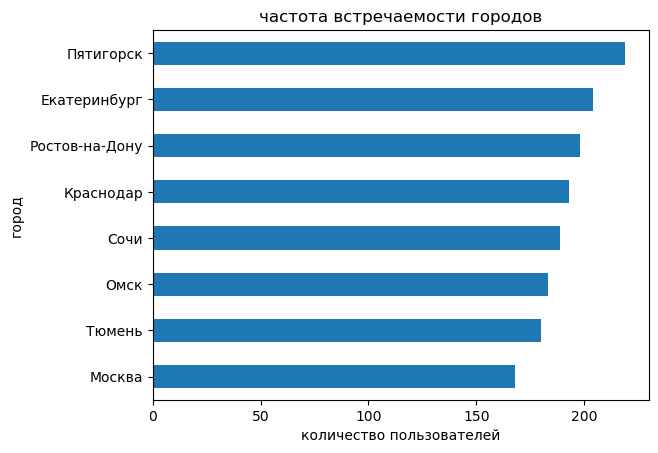

In [384]:
cities = users['city'].value_counts().sort_values()
fig = cities.plot.barh(title='частота встречаемости городов', 
                       xlabel='количество пользователей',
                       ylabel='город');
# fig.bar_label(fig.containers[0], label_type='edge');

*3.2 соотношение пользователей с подпиской и без подписки*

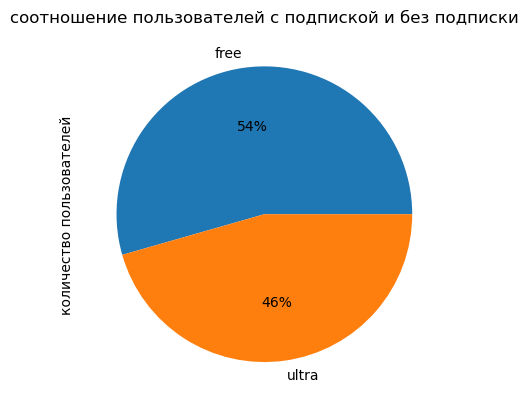

In [385]:
subscription_types = users['subscription_type'].value_counts() \
                            .sort_values(ascending=False)

fig = subscription_types.plot(title='соотношение пользователей с подпиской и без подписки', 
                              y='city', kind='pie', xlabel='тип подписки',
                              ylabel='количество пользователей',
                              autopct=lambda x: f"{x:.0f}%");
# fig.bar_label(fig.containers[0], label_type='edge');

*3.3 возраст пользователей*

count    1534.0
mean       24.9
std         4.6
min        12.0
25%        22.0
50%        25.0
75%        28.0
max        43.0
Name: age, dtype: object

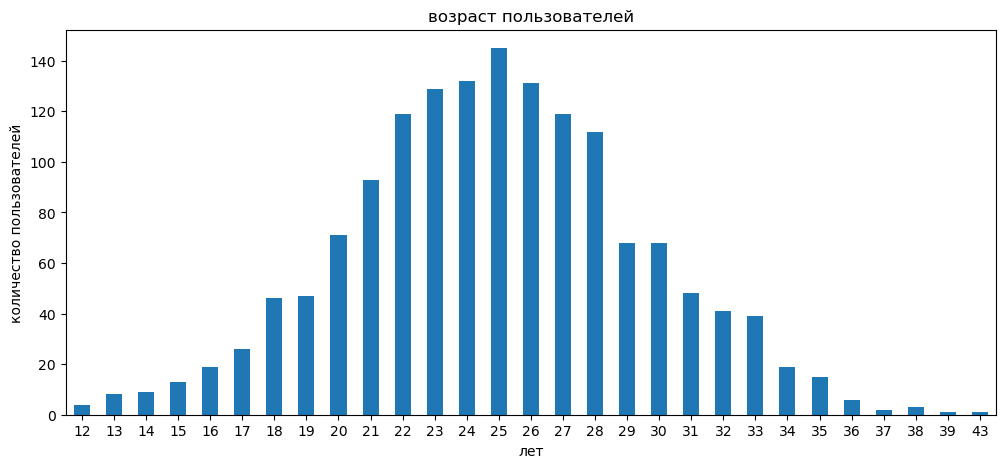

In [386]:
ages = users['age'].sort_values().value_counts(sort=False)
display(users['age'].describe().apply("{0:.1f}".format))
fig = ages.plot(title='возраст пользователей', y='age', kind='bar', 
                xlabel='лет', ylabel='количество пользователей', figsize=(12,5));
plt.xticks(rotation=0)
plt.show()


*3.4 расстояние, которое пользователь преодолел за одну поездку*

count    18068.0
mean      3070.7
std       1116.8
min          0.9
25%       2543.2
50%       3133.6
75%       3776.2
max       7211.0
Name: distance, dtype: object

Text(0.5, 0, 'м')

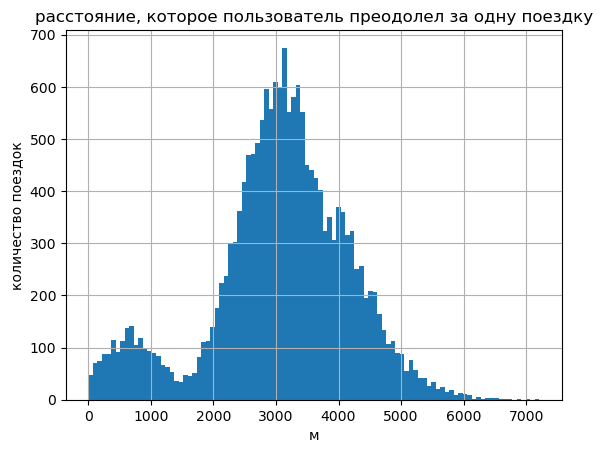

In [387]:
display(rides['distance'].describe().apply("{0:.1f}".format))
rides['distance'].hist(bins=100);
plt.title('расстояние, которое пользователь преодолел за одну поездку')
plt.ylabel("количество поездок")
plt.xlabel("м")

*3.5 продолжительность поездок*

count    18068.0
mean        18.3
std          6.1
min          1.0
25%         14.0
50%         18.0
75%         22.0
max         41.0
Name: duration, dtype: object

Text(0.5, 0, 'мин')

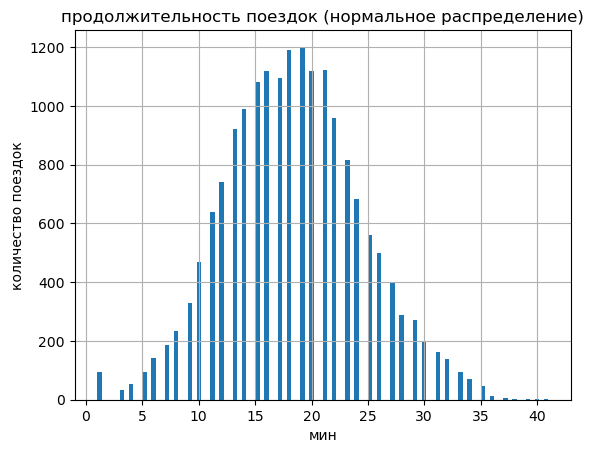

In [388]:
display(rides['duration'].describe().apply("{0:.1f}".format))
rides['duration'].hist(bins=100);
plt.title('продолжительность поездок (нормальное распределение)')
plt.ylabel("количество поездок")
plt.xlabel("мин")

Заодно оценим скорость.

count    18068.0
mean        11.8
std         22.0
min          0.0
25%          7.9
50%         10.0
75%         12.5
max        432.7
dtype: object

Text(0.5, 0, 'км/ч')

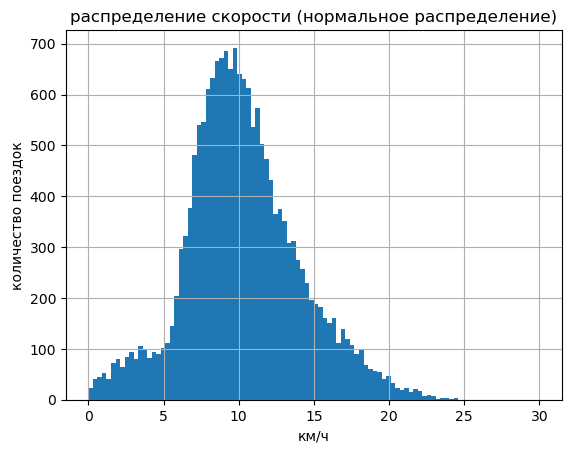

In [389]:
speed = (rides['distance']/1000/(rides['duration']/60))
display(speed.describe().apply("{0:.1f}".format))
speed.hist(bins=100, range=(0,30));
plt.title('распределение скорости (нормальное распределение)')
plt.ylabel("количество поездок")
plt.xlabel("км/ч")

<Axes: ylabel='month'>

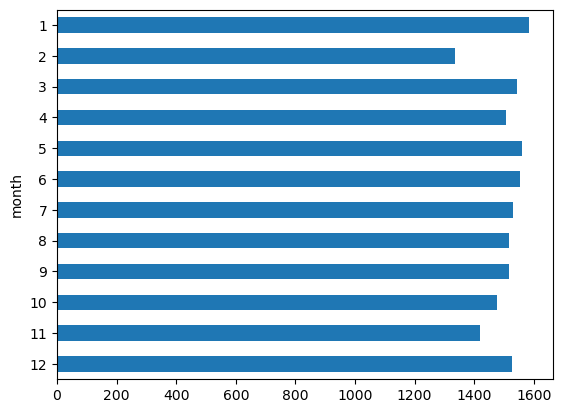

In [390]:
seasons = rides['month'].value_counts().sort_index(ascending=False)
seasons.plot.barh()

Меньше всего поездок в феврале и ноябре.

Больше всего в январе и декабре.

Это странно. Ожидалось увидеть провал зимой. Видимо в Пятигорске зимой можно кататься.

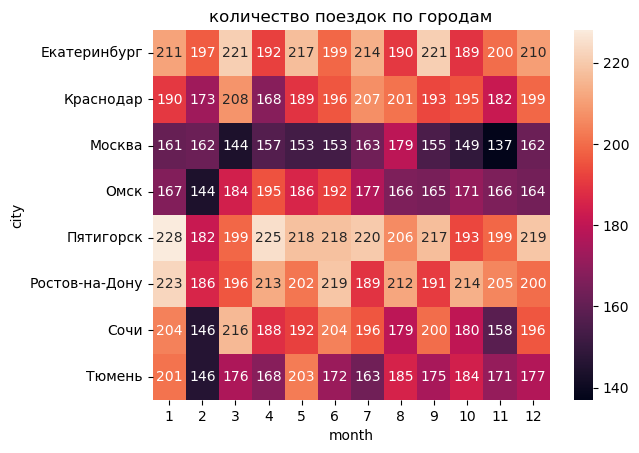

In [391]:
rides_with_cities = rides.merge(users, on='user_id', how='left')[['user_id','month','city']]
rides_with_cities_pivot = rides_with_cities.pivot_table(index='city', values='user_id', columns='month', aggfunc='count')
ax = plt.axes()
ax.set_title('количество поездок по городам')
sns.heatmap(rides_with_cities_pivot, ax = ax, annot=True, fmt='n');

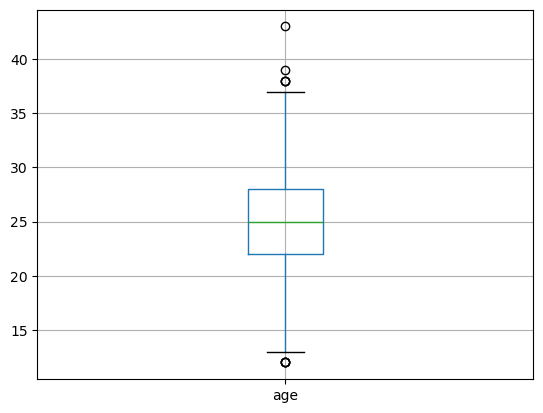

In [392]:
users.boxplot(column='age');

Средний возраст 25 лет. Однако есть аномально низкий возраст около 7 лет. Таким пользователям нельзя давать самокаты.

То, что возраст 37+ отнесён к аномалиям - статистически верно, но по факту не представляет собой проблемы.

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

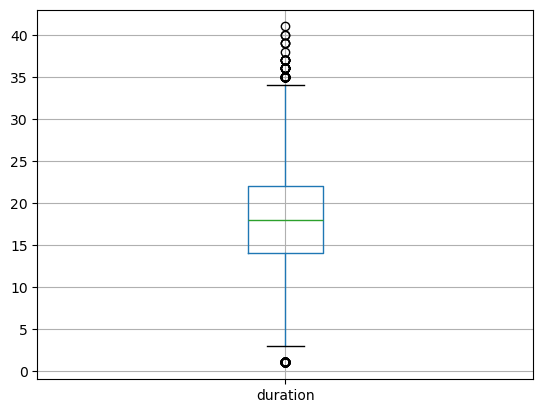

In [393]:
display(rides['distance'].describe())
rides.boxplot(column='duration');

Средняя продолжительность подездки 17 минут. Есть и очень долгие поездки около 40 минут. В целом, так бывает, аномалии в этом нет.

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

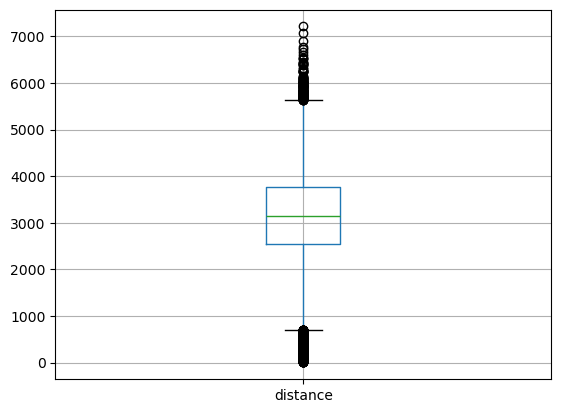

In [394]:
display(rides['distance'].describe())
rides.boxplot(column='distance');

То же самое. Средняя поездка - 3 км. Есть очень короткие и очень длинные - это вполне нормальные жизненные ситуации.

Общий промежуточный вывод - аномальной видятся только ситуация с допуском на самокаты детей (добавлено в итоговый отчёт). В остальном выглядит типично.

#### Шаг 4. Объединение данных

*4.1 Объедините данные о пользователях, поездках и подписках в один датафрейм.*

In [395]:
data = users.merge(rides, on='user_id', how='right')
data = data.merge(subscriptions, on='subscription_type', how='right')
data

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,700,Айдар,22,Омск,free,2515.690719,15.0,2021-01-02,1,8,50,0
1,700,Айдар,22,Омск,free,846.932642,17.0,2021-02-01,2,8,50,0
2,700,Айдар,22,Омск,free,4004.434142,21.0,2021-02-04,2,8,50,0
3,700,Айдар,22,Омск,free,1205.911290,10.0,2021-02-10,2,8,50,0
4,700,Айдар,22,Омск,free,3047.379435,18.0,2021-02-14,2,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,699,Оксана,22,Москва,ultra,3973.046497,25.0,2021-08-29,8,6,0,199
18064,699,Оксана,22,Москва,ultra,3288.702563,16.0,2021-09-12,9,6,0,199
18065,699,Оксана,22,Москва,ultra,3076.159348,15.0,2021-09-26,9,6,0,199
18066,699,Оксана,22,Москва,ultra,4707.845501,16.0,2021-10-17,10,6,0,199


In [396]:
display(len(rides))

display(len(data))

18068

18068

Размеры совпадают.

Проверим пропуски:

In [397]:
data.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Пропусков нет.

*4.2 Создайте ещё два датафрейма из датафрейма, созданного на этапе 4.1:*
- *c данными о пользователях без подписки;*
- *с данными о пользователях с подпиской.*

In [398]:
data_free = data.query('subscription_type=="free"')
data_ultra = data.query('subscription_type=="ultra"')

In [399]:
data_free.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [400]:
data_ultra.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Пропусков нет.

In [401]:
all_count = len(data)
free_count = len(data_free)
ultra_count = len(data_ultra)

display (f"{free_count} + {ultra_count} = {free_count+ultra_count} == {all_count}")

'11568 + 6500 = 18068 == 18068'

Размеры совпали.

*4.3 Визуализируйте информацию о расстоянии и времени поездок для пользователей обеих категорий.*

In [402]:
agg_func_describe = {'duration': ['describe'],'distance': ['describe']}
data.groupby(['subscription_type']).agg(agg_func_describe).round(1)

duration                                         distance  \
                  describe                                         describe   
                     count  mean  std  min   25%   50%   75%   max    count   
subscription_type                                                             
free               11568.0  17.9  6.3  1.0  13.0  18.0  22.0  35.0  11568.0   
ultra               6500.0  19.0  5.6  4.0  15.0  19.0  22.0  41.0   6500.0   

                                                                          
                                                                          
                     mean     std    min     25%     50%     75%     max  
subscription_type                                                         
free               3045.5  1246.2    0.9  2366.6  3114.6  3905.7  7211.0  
ultra              3115.4   836.9  244.2  2785.4  3148.6  3560.6  5699.8

Text(0.5, 0, 'м')

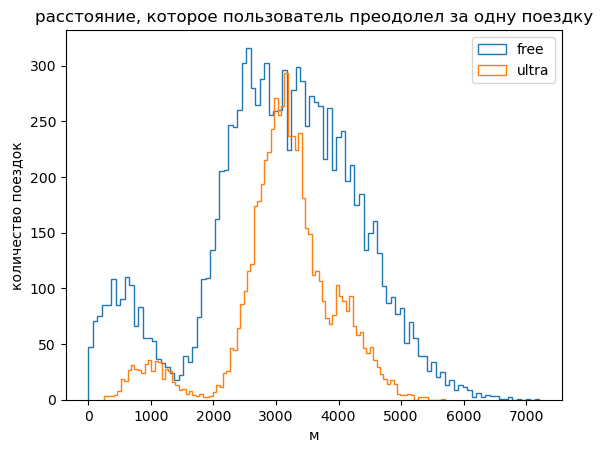

In [403]:
ax = data_free.plot(kind='hist', y = 'distance', histtype='step', 
                    bins=100, label='free');
data_ultra.plot(kind='hist', y = 'distance', histtype='step', 
                bins=100, ax=ax, label='ultra');
plt.title('расстояние, которое пользователь преодолел за одну поездку')
plt.ylabel("количество поездок")
plt.xlabel("м")

Text(0.5, 0, 'м')

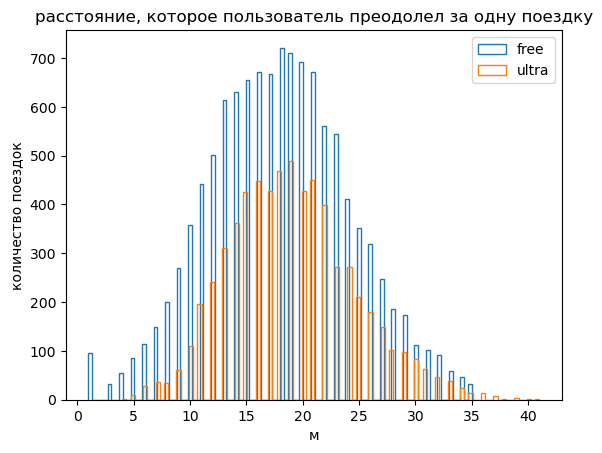

In [404]:
ax = data_free.plot(kind='hist', y = 'duration', histtype='step', 
                    bins=100, label='free');
data_ultra.plot(kind='hist', y = 'duration', histtype='step', 
                bins=100, ax=ax, label='ultra');
plt.title('расстояние, которое пользователь преодолел за одну поездку')
plt.ylabel("количество поездок")
plt.xlabel("м")

Ultra ездит на большем диапазоне расстояний, берёт самокат даже на короткие расстояния. Free решается на поездки более длинные (видимо, на короткие расстояния жалко стартовых 50 р. и предпочитают пройтись пешком) Аналогичные выводы по продолжительности.

Также имеется пик продолжительности около нуля для ultra. Возможно, это связано с тем, что ultra-пользователей очень короткие поездки почти ничего не стоят, и они себе в них не отказывают.

#### Шаг 5. Подсчёт выручки

*5.1 Создайте датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными из шага 4: найдите суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.*

In [405]:
data[:2]

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,700,Айдар,22,Омск,free,2515.690719,15.0,2021-01-02,1,8,50,0
1,700,Айдар,22,Омск,free,846.932642,17.0,2021-02-01,2,8,50,0


In [406]:
income_pivot = data.assign(month = data.date.dt.month) \
    .pivot_table(index=['user_id','month'],
                 aggfunc={'distance':'sum','user_id':'count','duration':'sum'})
income_pivot = income_pivot.rename(columns={'user_id':'rides_count'})
display(income_pivot)

distance  duration  rides_count
user_id month                                     
1       1       7027.511294      42.0            2
        4        754.159807       7.0            1
        8       6723.470560      46.0            2
        10      5809.911100      32.0            2
        11      7003.499363      56.0            3
...                     ...       ...          ...
1534    6       3409.468534      26.0            2
        8       7622.453034      48.0            2
        9       4928.173852      23.0            1
        11     13350.015305      78.0            4
        12      2371.711192      16.0            1

[11331 rows x 3 columns]

In [407]:
income_pivot.isna().sum()

distance       0
duration       0
rides_count    0
dtype: int64

*5.2 В этот же датафрейм добавьте столбец с помесячной выручкой, которую принёс каждый пользователь. Для этого обратитесь к информации об условиях оплаты для подписчиков и тех, у кого нет подписки.*

In [408]:
rides_pivot = data.pivot_table(index=['user_id','month'],
                               aggfunc={'subscription_type':'first',
                                        'minute_price':'first', 
                                        'start_ride_price':'first', 
                                        'subscription_fee':'first'})
income_pivot = income_pivot.join(rides_pivot, how='left')

income_pivot ['monthly_income'] = income_pivot.apply(lambda d: d['subscription_fee']+ 
                                         d['start_ride_price']*d['rides_count'] + 
                                         d['minute_price']*np.ceil(d['duration']),
                                         axis=1)
display(income_pivot)

distance  duration  rides_count  minute_price  \
user_id month                                                      
1       1       7027.511294      42.0            2             6   
        4        754.159807       7.0            1             6   
        8       6723.470560      46.0            2             6   
        10      5809.911100      32.0            2             6   
        11      7003.499363      56.0            3             6   
...                     ...       ...          ...           ...   
1534    6       3409.468534      26.0            2             8   
        8       7622.453034      48.0            2             8   
        9       4928.173852      23.0            1             8   
        11     13350.015305      78.0            4             8   
        12      2371.711192      16.0            1             8   

               start_ride_price  subscription_fee subscription_type  \
user_id month                                                         
1       1                     0               199             ultra   
        4                     0               199             ultra   
        8                     0               199             ultra   
        10                    0               199             ultra   
        11                    0               199             ultra   
...                         ...               ...               ...   
1534    6                    50                 0              free   
        8                    50                 0              free   
        9                    50                 0              free   
        11                   50                 0              free   
        12                   50                 0              free   

               monthly_income  
user_id month                  
1       1               451.0  
        4               241.0  
        8               475.0  
        10              391.0  
        11              535.0  
...                       ...  
1534    6               308.0  
        8               484.0  
        9               234.0  
        11              824.0  
        12              178.0  

[11331 rows x 8 columns]

In [409]:
# check
income_pivot['monthly_income'].sum()

3878641.0

In [410]:
ultra_pivot = income_pivot.loc[income_pivot['subscription_type']=='ultra']
free_pivot = income_pivot.loc[income_pivot['subscription_type']=='free']

# display(f'Среднемесячная выручка подписчика: {ultra_pivot['monthly_income'].mean():.2f}')
# display(f'Среднемесячная выручка бесплатного пользователя: {free_pivot['monthly_income'].mean():.2f}')


Рассчитаем
+ сравнение показателей суммарной годовой выручки для каждого тарифа и среднемесячной выручки для среднего пользователя, также для каждого тарифа
+ условно, 1 млн. руб. за год мы заработали на пользователях с подпиской и 2 млн. руб. на пользователях без подписки 

In [411]:
ultra_monthly_avg = ultra_pivot['monthly_income'].mean()
free_monthly_avg = free_pivot['monthly_income'].mean()
ultra_year = ultra_pivot['monthly_income'].sum()
free_year = free_pivot['monthly_income'].sum()

display(f'Среднемесячная выручка подписчика: {ultra_monthly_avg:.2f}')
display(f'Среднемесячная выручка бесплатного пользователя: {free_monthly_avg:.2f}')
display(f'Годовая выручка подписчика: {ultra_year}')
display(f'Годовая выручка бесплатного пользователя: {free_year}')

'Среднемесячная выручка подписчика: 362.79'

'Среднемесячная выручка бесплатного пользователя: 328.64'

'Годовая выручка подписчика: 1644537.0'

'Годовая выручка бесплатного пользователя: 2234104.0'

#### Шаг 6. Проверка гипотез

*6.1 Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверьте гипотезу. Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.*

In [412]:
H0 = "подписчики в среднем тратят столько же времени на поездки, \
    сколько и пользователи без подписки"
H1 = "(правосторонняя) подписчики в среднем тратят больше времени на поездки, чем пользователи без подписки"

In [413]:
alpha = 0.01 # возьмём уровень статистической значимости

results = st.ttest_ind(data_ultra['duration'], data_free['duration'], alternative='greater')

print_hypothesis(results.pvalue, alpha, H0, H1)

pvalue 2.4959453720736625e-34 ~0.000 менее уровня значимости 0.01, потому мы отвергаем H0 и принимаем H1:
(правосторонняя) подписчики в среднем тратят больше времени на поездки, чем пользователи без подписки


Вывод
- рассчитанное p-value ~0.00 меньше заданного уровня значимости 0.01, поэтому нулевая гипотеза отвергается.
- бизнесу выгоднее пользователи с подпиской, т. к. в среднем они тратят больше времени на поездки (уровень значимости 0.01).

In [414]:
# Приведены два датасета: сумма покупок, совершённых за месяц посетителями ...

sample_1 = [3071, 3636, 3454, 3151, 2185, 3259, 1727, 2263, 2015,
2582, 4815, 633, 3186, 887, 2028, 3589, 2564, 1422, 1785,
3180, 1770, 2716, 2546, 1848, 4644, 3134, 475, 2686,
1838, 3352]
sample_2 = [1211, 1228, 2157, 3699, 600, 1898, 1688, 1420, 5048, 3007,
509, 3777, 5583, 3949, 121, 1674, 4300, 1338, 3066,
3562, 1010, 2311, 462, 863, 2021, 528, 1849, 255,
1740, 2596]
alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу
results = st.ttest_ind(
sample_1,
sample_2)
print('p-значение:', results.pvalue)
if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.1912450522572209
Не получилось отвергнуть нулевую гипотезу


*6.2 Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверьте гипотезу и сделайте выводы.*

In [415]:
H0 = "среднее расстояние, которое проезжают подписчики за одну поездку равно 3130 метров"
H1 = "(левосторонняя) среднее расстояние, которое проезжают подписчики за одну поездку менее 3130 метров"

In [416]:
interested_value = 3130 # оптимальный пробег в плане износа самоката

alpha = 0.01 #  уровень статистической значимости

results = st.ttest_1samp(data_ultra['distance'], interested_value, alternative='less')

print_hypothesis(results.pvalue, alpha, H0, H1)

pvalue 0.08046311521502146 ~0.080 равен или больше уровня значимости 0.01, потому мы не можем отвергнуть H0:
среднее расстояние, которое проезжают подписчики за одну поездку равно 3130 метров


In [417]:
H0 = "среднее расстояние, которое проезжают подписчики за одну поездку равно 3130 метров"
H1 = "(правосторонняя) среднее расстояние, которое проезжают подписчики за одну поездку более 3130 метров"

In [418]:
interested_value = 3130 # оптимальный пробег в плане износа самоката

alpha = 0.01 #  уровень статистической значимости

results = st.ttest_1samp(data_ultra['distance'], interested_value, alternative='greater')

print_hypothesis(results.pvalue, alpha, H0, H1)

pvalue 0.9195368847849785 ~0.920 равен или больше уровня значимости 0.01, потому мы не можем отвергнуть H0:
среднее расстояние, которое проезжают подписчики за одну поездку равно 3130 метров


Вывод: нельзя сказать, что средний пробег значимо больше или значимо меньше  3130 м (уровень значимости 0.01)

*6.3 Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. Сделайте вывод.*

In [419]:
H0 = "помесячная выручка от пользователей с подпиской по месяцам равна \
выручке от пользователей без подписки"

H1 = "(правосторонняя) помесячная выручка от пользователей с подпиской \
по месяцам выше, чем выручка от пользователей без подписки"

In [420]:
alpha = 0.01 # уровень статистической значимости

results = st.ttest_ind(ultra_pivot['monthly_income'], 
                       free_pivot['monthly_income'],
                       alternative='greater') 

print_hypothesis(results.pvalue, alpha, H0, H1)

pvalue 1.8850394384715216e-31 ~0.000 менее уровня значимости 0.01, потому мы отвергаем H0 и принимаем H1:
(правосторонняя) помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки


Вывод: - средняя помесячная выручка от подписчиков выше, чем средняя помесячная выручка от пользователей без подписки (уровень значимости 0.01)

*6.4 Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?*

Это гипотеза о равенстве среднего генеральной совокупности для зависимых (парных) выборок.

Её проверяют функцией st.ttest_rel

In [432]:
H0 = "в следствие обновления мобильного приложения \
количество обращений в техподдержку осталось таким же как и было до обновления"

H1 = "благодаря обновлению мобильного приложения \
количество обращений в техподдержку значимо снизилось"

In [436]:
from scipy import stats as st

before = [157, 114, 152, 355, 155, 513, 299, 268, 164, 320, 
          192, 262, 506, 240, 364, 179, 246, 427, 187, 431, 
          320, 193, 313, 347, 312, 92, 177, 225, 242, 312]

after = [282, 220, 162, 226, 296, 479, 248, 322, 298, 418, 
         552, 246, 251, 404, 368, 484, 358, 264, 359, 410, 
         382, 350, 406, 416, 438, 364, 283, 314, 420, 218]

alpha = 0.05 # уровень статистической значимости

# ‘greater’: the mean of the distribution underlying the first sample is greater
# than the mean of the distribution underlying the second sample.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html
# мы как раз и хотим в H1 удостовериться, что было больше обращений а стало меньше:
results = st.ttest_rel(before, after, alternative='greater')

print_hypothesis(results.pvalue, alpha, H0, H1)

pvalue 0.9970870137710205 ~0.997 равен или больше уровня значимости 0.05, потому мы не можем отвергнуть H0:
из-за обновления мобильное приложение количество обращений в техподдержку осталось таким же как и было до обновления


Вывод: из-за обновления мобильное приложение количество обращений в техподдержку значимо снизилось (уровень значимости 0.05)

#### Шаг 7. Распределения

*7.1 Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 
Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10% пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5%. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.*

Чисто интуитивно кажется, что нужно раздать 1000 промокодов, чтобы 10% от них, исходя из предыдущей статистики, то есть 100 человек, оставили бы себе подписку.

В то же время, чем меньшим числом промокодов мы этого добьёмся, тем больше сэкономим.

Распределение тут биномиальное. Эксперимент Бернулли в нашем случае = успех или неуспех продления подписки.

In [423]:
display(st.binom.cdf(100, 500, 0.1))   

0.9999999999921443

In [424]:
display(st.binom.cdf(100, 1000, 0.1))  

0.5265990812951653

In [425]:
display(st.binom.cdf(100, 1500, 0.1))

3.514339303482772e-06

Для 1000 площадь распределения больше 5%, при 1500 сильно больше. Подберём нужное значение между ними.

In [426]:
l = 1000
r = 1500
while l < r-1:
    m = int((l+r)/2)
    b = st.binom.cdf(100, m, 0.1)
    if (b < 0.05):
        r = m
    else:
        l = m
display (f'искомый n: {l}, площадь биномиального распределения левее 100 {b}')

'искомый n: 1171, площадь биномиального распределения левее 100 0.04954795210203071'

In [427]:
st.binom.cdf(100, 1170, 0.1)

0.05151491673741622

Вывод: при 1171 - минимальное количество промокодов, при котором верятность не выполнить план не более 5%

График распределения:

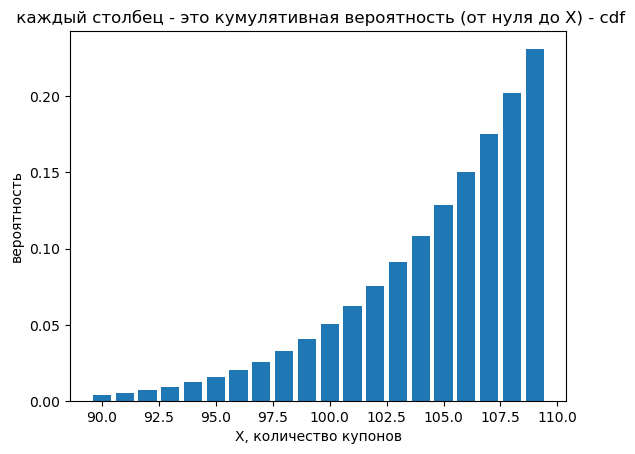

In [428]:
#  список distr, в котором будем хранить значения распределения
distr=[]
cdfs=[]

n = 1171
p = 0.1

for k in range(90, 110):
    cdfs.append(st.binom.cdf(k, n, p))

plt.bar(range(90, 110), cdfs)
plt.title(' каждый столбец - это кумулятивная вероятность (от нуля до X) - cdf')
plt.ylabel("вероятность")
plt.xlabel("X, количество купонов")
plt.show()

Графики подтверждают вывод: при 1171 разданных купонов - нужная кумулятивная вероятность в 5% набирается около 100 человек, которые продлят подписку.

*7.2 Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40% получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.*

In [429]:
n = 1000000
p = 0.4

mu = n * p
sigma = sqrt(n * p * (1 - p))

distr = st.norm(mu, sigma) 

result = distr.cdf(399500)
display(result)

0.15371708296369768

Вероятность, что при отправке 1 млн уведомлений его откроют не более 399,5 тыс. пользователей ~15%.

Вывод: это хорошо для бизнеса, т. к. с вероятностью 85% сообщение откроют 399,5+ тыс. пользователей.

Построим график:

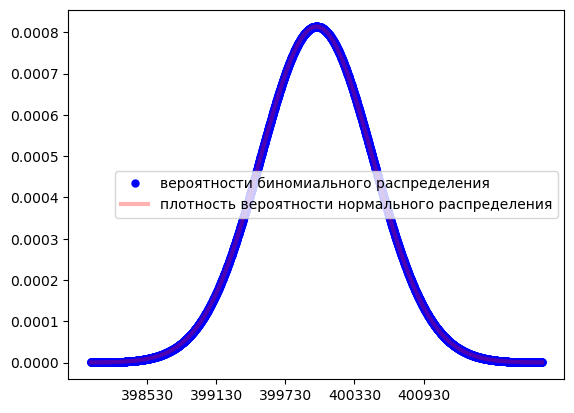

In [430]:
def linspace(start, stop, num):
    step = (stop - start) / (num - 1)
    result = []
    for i in range(num):
        result.append(start + step * i)
    return result
 
# границы промежутка, в котором будем строить аппроксимацию -
# от n*p минус 4 ст.отклонения бином.распределения
# до n*p плюс 4 ст.отклонения бином.распределения
# (там, где вероятности значений почти не равны нулю)
left = int(n * p - 4 * sqrt(n * p * (1 - p)))
right = int(n * p + 4 * sqrt(n * p * (1 - p)))
 
# зададим набор значений биномиальной величины на выбранном промежутке:
# все неотрицательные целые числа от left до right
x = list(range(max(0, left), right))
# рисуем график биномиального распределения
ax = plt.subplot()
# используем синие о-образные маркеры и размер маркера 5
ax.plot(x, st.binom.pmf(x, n, p), 'bo', ms=5,
	      label='вероятности биномиального распределения')

# рисуем график нормального распределения:
# получим список из 100 чисел от left до right
x = linspace(left, right, 100)
# используем красную линию ширины 3 и прозрачности 0.3
ax.plot(x, st.norm.pdf(x, mu, sigma), 'r-', lw=3, alpha=0.3, label='плотность вероятности нормального распределения')
 
# зададим подписи по оси x в пределах ± 3 ст.отклонений от мат.ожидания
# (последний аргумент в методе range - интервал между подписями)
x_ticks = list(range(int(mu - 3 * sigma), int(mu + 3 * sigma), 600))
ax.set_xticks(x_ticks)

# настраиваем оптимальное расположение легенды и выводим график
ax.legend(loc='best')
plt.show()

# Отчёт

Исследование основано на данных с 2021-01-01 по 2021-12-30.

## Главные выводы

Вывод для бизнеса:
- Пописчики выгоднее для бизнеса, чем пользователи без подписки:
    - Годовая выручка подписчика: 1 638 597 р.
    - Годовая выручка бесплатного пользователя: 2 215 080 р.


Выводы по гипотезам:
- бизнесу выгоднее пользователи с подпиской, т. к. в среднем они тратят больше времени на поездки (уровень значимости 0.01)
- нельзя сказать, что средний пробег значимо превышает 3130 м (уровень значимости 0.01)
- помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки
- 1171 - минимальное количество промокодов, при котором верятность не выполнить план не более 5%
- Вероятность, что при отправке 1 млн уведомлений его откроют не более 399,5 тыс. пользователей ~15%.
- Средний возраст 25 лет. Однако есть аномально низкий возраст около 7 лет. Таким пользователям нельзя давать самокаты.

## Сопутствующая информация

Результаты педобработки данных:
- поле data приведено к типу даты
- добавлено поле с номером месяца
- пропусков не нашлось
- найден один полный дубликат пользователя user_id=209


Результаты исследования данных:
- Наиболее частые в данном датасете города: Пятигорск, Екатеринбург, Ростов-на-Дону. Нетипично, но, возможно это связано с хронологией выхода на эти рынки или с какими-то ограничениями по сбору датасета.
- Не выражена сезонность в Москве, хотя зимой не должно быть поездок. Вероятно, что-то не так с данными - нужно обсудить этот вопрос с теми, кто их собирает.
- Бесплатных пользователей больше, чем подписчиков (835 против 699)
- ultra ездит на большем диапазоне расстояний, берёт самокат даже на короткие расстояния. Free решается на поездки более длинные (видимо, на короткие расстояния жалко стартовых 50 р. и предпочитают пройтись пешком.)
- имеется пик продолжительности около нуля для ultra. Возможно, это связано с тем, что ultra-пользователей очень короткие поездки почти ничего не стоят, и они себе в них не отказывают.
- средний возраст пользователей 25 лет
- среднее расстояние поездки 3 км
- средняя продолжительность поездки 17 минут
- средняя скорость 14 км/ч
- среднемесячная выручка подписчика 361 р.
- среднемесячная выручка бесплатного пользователя 325 р.
- обнаружены странности в данных в зимнее время года.